# PricePulse Demo: African Food Price Intelligence

This notebook demonstrates key insights from the PricePulse platform, which monitors food prices across 6 African countries covering 360+ million people

## Dataset Overview
- **6 countries**: Kenya, Nigeria, Mali, Mozambique, Senegal, Somalia
- **36,143 observations** across 404 markets
- **5 regions**: East Africa, West Africa, Sahel, Southern Africa, Horn of Africa
- **18 years of data**: 2007-2025

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("PricePulse Demo Notebook")

PricePulse Demo Notebook


## 1. Load the Unified Dataset

In [7]:
# Load the unified 6-country dataset
df = pd.read_csv('data_sources/processed/unified_six_country.csv')
df['price_date'] = pd.to_datetime(df['price_date'])

print(f"Dataset loaded successfully!")
print(f"• Total observations: {len(df):,}")
print(f"• Countries: {df['country'].nunique()}")
print(f"• Markets: {df['mkt_name'].nunique()}")
print(f"• Date range: {df['price_date'].min().strftime('%Y-%m-%d')} to {df['price_date'].max().strftime('%Y-%m-%d')}")

# Show country breakdown
print("\nCountry Coverage:")
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    print(f"• {country}: {len(country_data):,} observations, {country_data['mkt_name'].nunique()} markets, {country_data['region'].iloc[0]}")

Dataset loaded successfully!
• Total observations: 36,143
• Countries: 6
• Markets: 404
• Date range: 2007-01-01 to 2025-06-01

Country Coverage:
• Kenya: 1,144 observations, 14 markets, East Africa
• Nigeria: 2,754 observations, 60 markets, West Africa
• Mali: 15,143 observations, 127 markets, Sahel
• Mozambique: 4,564 observations, 96 markets, Southern Africa
• Senegal: 9,054 observations, 64 markets, West Africa
• Somalia: 3,484 observations, 43 markets, Horn of Africa


## 2. Regional Analysis: Data Distribution

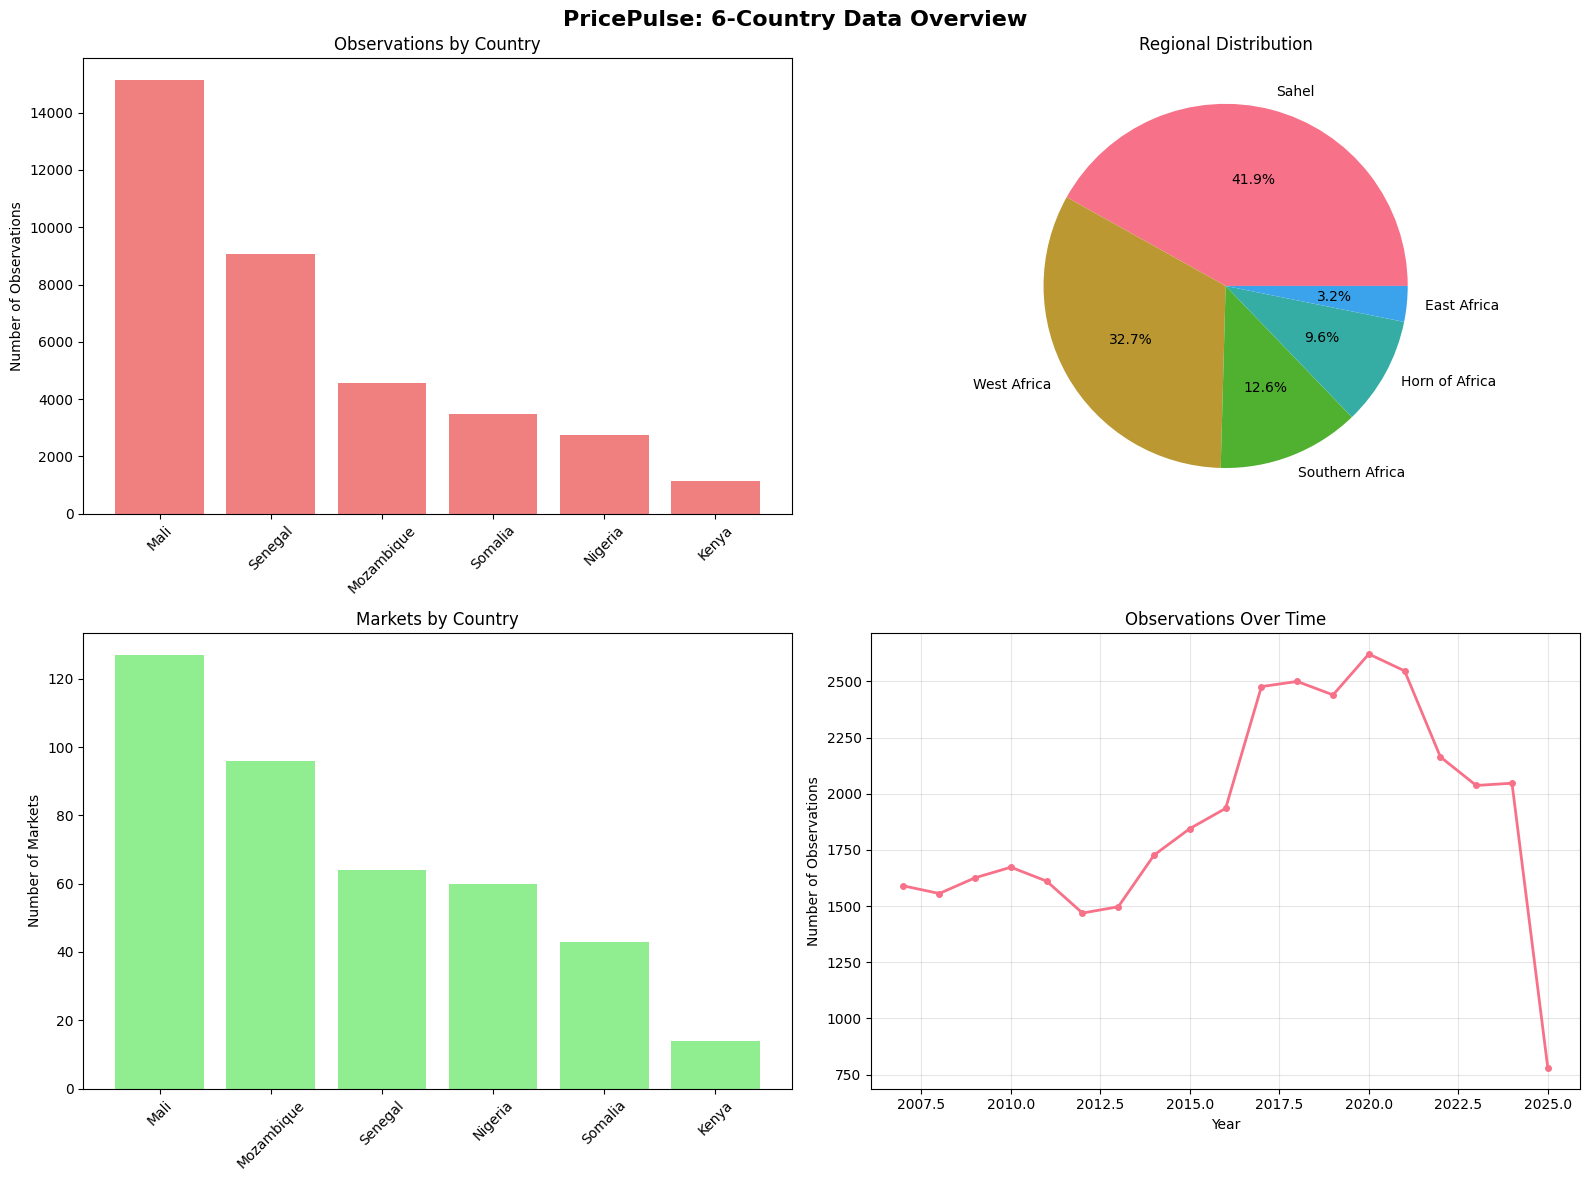


Key Insights:
• Mali provides the highest data volume: 15,143 observations
• Sahel region dominates with 15,143 observations


In [8]:
# Create visualization showing data distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PricePulse: 6-Country Data Overview', fontsize=16, fontweight='bold')

# 1. Observations by country
country_counts = df['country'].value_counts()
axes[0, 0].bar(country_counts.index, country_counts.values, color='lightcoral')
axes[0, 0].set_title('Observations by Country')
axes[0, 0].set_ylabel('Number of Observations')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Regional distribution
region_counts = df['region'].value_counts()
axes[0, 1].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%')
axes[0, 1].set_title('Regional Distribution')

# 3. Markets by country
market_counts = df.groupby('country')['mkt_name'].nunique().sort_values(ascending=False)
axes[1, 0].bar(market_counts.index, market_counts.values, color='lightgreen')
axes[1, 0].set_title('Markets by Country')
axes[1, 0].set_ylabel('Number of Markets')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Data timeline
df['year'] = df['price_date'].dt.year
yearly_obs = df.groupby('year').size()
axes[1, 1].plot(yearly_obs.index, yearly_obs.values, marker='o', linewidth=2, markersize=4)
axes[1, 1].set_title('Observations Over Time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Observations')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"• Mali provides the highest data volume: {country_counts['Mali']:,} observations")
print(f"• Sahel region dominates with {region_counts.get('Sahel', 0):,} observations")

## 3. Cross-Country Commodity Analysis: Sorghum

In [13]:
# Analyze sorghum prices across countries (available in 5/6 countries!)
print("SORGHUM CROSS-COUNTRY ANALYSIS")
print()

# Find countries with sorghum data
sorghum_countries = []
sorghum_data = []

for country in df['country'].unique():
    country_df = df[df['country'] == country]
    if 'sorghum' in country_df.columns and not country_df['sorghum'].isna().all():
        sorghum_subset = country_df[country_df['sorghum'].notna()]
        if len(sorghum_subset) > 0:
            sorghum_countries.append(country)
            avg_price = sorghum_subset['sorghum'].mean()
            currency = sorghum_subset['currency'].iloc[0]
            observations = len(sorghum_subset)
            sorghum_data.append({
                'country': country,
                'avg_price': avg_price,
                'currency': currency,
                'observations': observations
            })

print(f"Sorghum data available in {len(sorghum_countries)} countries: {', '.join(sorghum_countries)}")
print("\nAverage sorghum prices by country:")
for data in sorghum_data:
    print(f"• {data['country']}: {data['avg_price']:.0f} {data['currency']} (from {data['observations']} observations)")

SORGHUM CROSS-COUNTRY ANALYSIS

Sorghum data available in 5 countries: Kenya, Nigeria, Mali, Senegal, Somalia

Average sorghum prices by country:
• Kenya: 3674 KES (from 425 observations)
• Nigeria: 754 NGN (from 1201 observations)
• Mali: 207 XOF (from 8356 observations)
• Senegal: 248 XOF (from 4115 observations)
• Somalia: 16720 SOS (from 1988 observations)


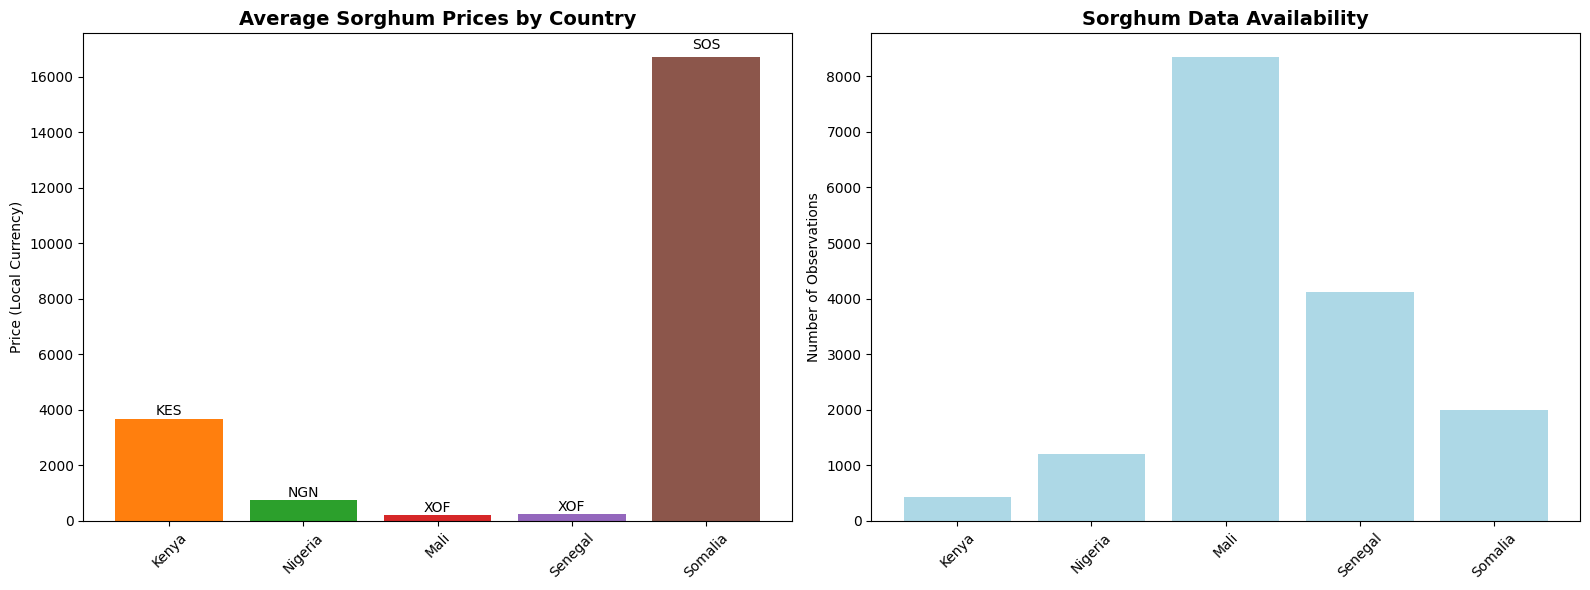


Key Insight: Massive price differences suggest potential trade arbitrage opportunities!


In [14]:
# Visualize sorghum price comparison
if len(sorghum_data) > 1:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Price comparison chart
    countries = [d['country'] for d in sorghum_data]
    prices = [d['avg_price'] for d in sorghum_data]
    currencies = [d['currency'] for d in sorghum_data]
    
    bars = ax1.bar(countries, prices, color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(countries)])
    ax1.set_title('Average Sorghum Prices by Country', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (Local Currency)')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add currency labels on bars
    for bar, currency in zip(bars, currencies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{currency}', ha='center', va='bottom', fontsize=10)
    
    # Observations count
    obs_counts = [d['observations'] for d in sorghum_data]
    ax2.bar(countries, obs_counts, color='lightblue')
    ax2.set_title('Sorghum Data Availability', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Observations')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\nKey Insight: Massive price differences suggest potential trade arbitrage opportunities!")

## 4. Summary: Platform Capabilities

In [16]:
print("PRICEPULSE PLATFORM SUMMARY")
print()

# Calculate key statistics
total_obs = len(df)
total_countries = df['country'].nunique()
total_markets = df['mkt_name'].nunique()
total_regions = df['region'].nunique()
date_span = (df['price_date'].max() - df['price_date'].min()).days / 365.25

print(f"SCALE ACHIEVED:")
print(f"• {total_obs:,} price observations")
print(f"• {total_countries} countries across {total_regions} African regions")
print(f"• {total_markets} markets monitored")
print(f"• {date_span:.1f} years of historical data")

print(f"\nCROSS-COUNTRY INTELLIGENCE:")
print(f"• Sorghum available in {len(sorghum_countries)} countries - perfect for pan-African analysis")
print(f"• Regional food system comparisons across diverse agricultural zones")
print(f"• Conflict zone monitoring capabilities")

print(f"\nBUSINESS APPLICATIONS:")
print(f"• Early warning systems for food crises")
print(f"• Trade policy analysis for regional economic communities")
print(f"• Investment decisions for agricultural development")
print(f"• Cross-border trade arbitrage identification")

print(f"\nPlatform ready for scaling to 10+ countries!")

PRICEPULSE PLATFORM SUMMARY

SCALE ACHIEVED:
• 36,143 price observations
• 6 countries across 5 African regions
• 404 markets monitored
• 18.4 years of historical data

CROSS-COUNTRY INTELLIGENCE:
• Sorghum available in 5 countries - perfect for pan-African analysis
• Regional food system comparisons across diverse agricultural zones
• Conflict zone monitoring capabilities

BUSINESS APPLICATIONS:
• Early warning systems for food crises
• Trade policy analysis for regional economic communities
• Investment decisions for agricultural development
• Cross-border trade arbitrage identification

Platform ready for scaling to 10+ countries!
